# Model Explainability

## Student Mental Health Analyzer

---

## Objective

The purpose of this notebook is to understand how the trained Logistic Regression model makes predictions.

Unlike black-box models, Logistic Regression provides interpretable coefficients that indicate how each feature contributes to the prediction.

This notebook identifies:

- The most influential factors associated with depression.
- Features that increase prediction risk.
- Features that decrease prediction risk.
- Individual-level explanations that will later power the recommendation engine.

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

pd.set_option("display.max_columns", None)

In [21]:
model = joblib.load("../models/best_model.pkl")

In [22]:
X_train = pd.read_csv("../data/final/X_train.csv")
X_test = pd.read_csv("../data/final/X_test.csv")

y_train = pd.read_csv("../data/final/y_train.csv").squeeze()
y_test = pd.read_csv("../data/final/y_test.csv").squeeze()

In [23]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

Training Features: (22249, 38)
Testing Features: (5563, 38)


In [24]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

coef_df.head(20)

,Feature,Coefficient,Absolute Coefficient
7,Have you ever had suicidal thoughts ?,2.498136,2.498136
2,Academic Pressure,0.857620,0.857620
36,Degree_Others,0.704759,0.704759
9,Financial Stress,0.556725,0.556725
6,Dietary Habits,-0.544967,0.544967
23,Degree_LLM,0.532322,0.532322
21,Degree_BSc,0.350154,0.350154
25,Degree_M.Ed,0.338703,0.338703
31,Degree_MCA,0.317404,0.317404
22,Degree_LLB,0.298838,0.298838


In [25]:
# Remove one-hot encoded Degree features
coef_df = coef_df[~coef_df["Feature"].str.startswith("Degree_")]

# (Optional) Remove other non-actionable features
coef_df = coef_df[
    ~coef_df["Feature"].isin([
        "Age",
        "Gender",
        "Family History of Mental Illness"
    ])
]

## Understanding Logistic Regression Coefficients

Each coefficient represents the influence of a feature on the model's prediction.

- Positive coefficient → increases the likelihood of depression.
- Negative coefficient → decreases the likelihood of depression.

The larger the magnitude, the stronger the influence.

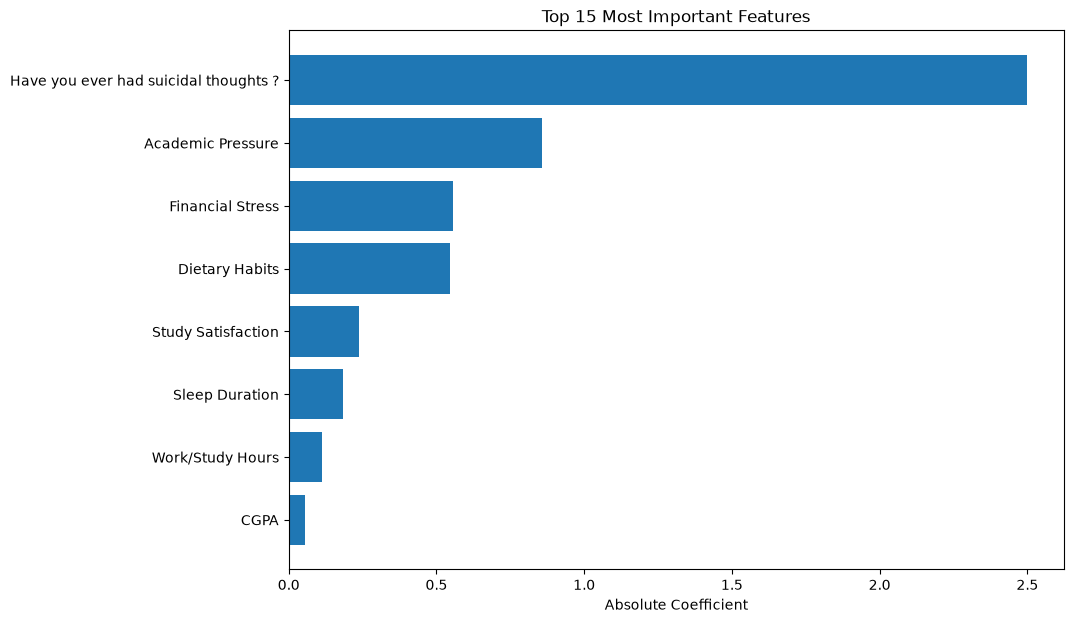

In [26]:
top = coef_df.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top["Feature"],
    top["Absolute Coefficient"]
)

plt.xlabel("Absolute Coefficient")

plt.title("Top 15 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

In [27]:
positive = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

positive.head(15)

,Feature,Coefficient,Absolute Coefficient
7,Have you ever had suicidal thoughts ?,2.498136,2.498136
2,Academic Pressure,0.857620,0.857620
9,Financial Stress,0.556725,0.556725
8,Work/Study Hours,0.112493,0.112493
3,CGPA,0.054379,0.054379
5,Sleep Duration,-0.182967,0.182967
4,Study Satisfaction,-0.238127,0.238127
6,Dietary Habits,-0.544967,0.544967


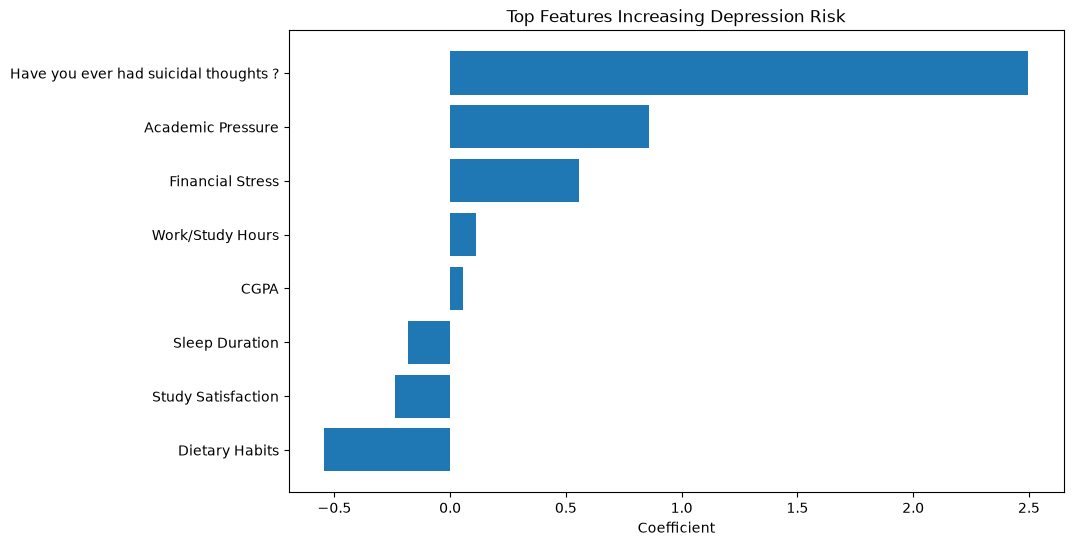

In [28]:
plt.figure(figsize=(10,6))

plt.barh(
    positive.head(10)["Feature"],
    positive.head(10)["Coefficient"]
)

plt.title("Top Features Increasing Depression Risk")

plt.xlabel("Coefficient")

plt.gca().invert_yaxis()

plt.show()

In [29]:
negative = coef_df.sort_values(
    "Coefficient"
)

negative.head(15)

,Feature,Coefficient,Absolute Coefficient
6,Dietary Habits,-0.544967,0.544967
4,Study Satisfaction,-0.238127,0.238127
5,Sleep Duration,-0.182967,0.182967
3,CGPA,0.054379,0.054379
8,Work/Study Hours,0.112493,0.112493
9,Financial Stress,0.556725,0.556725
2,Academic Pressure,0.857620,0.857620
7,Have you ever had suicidal thoughts ?,2.498136,2.498136


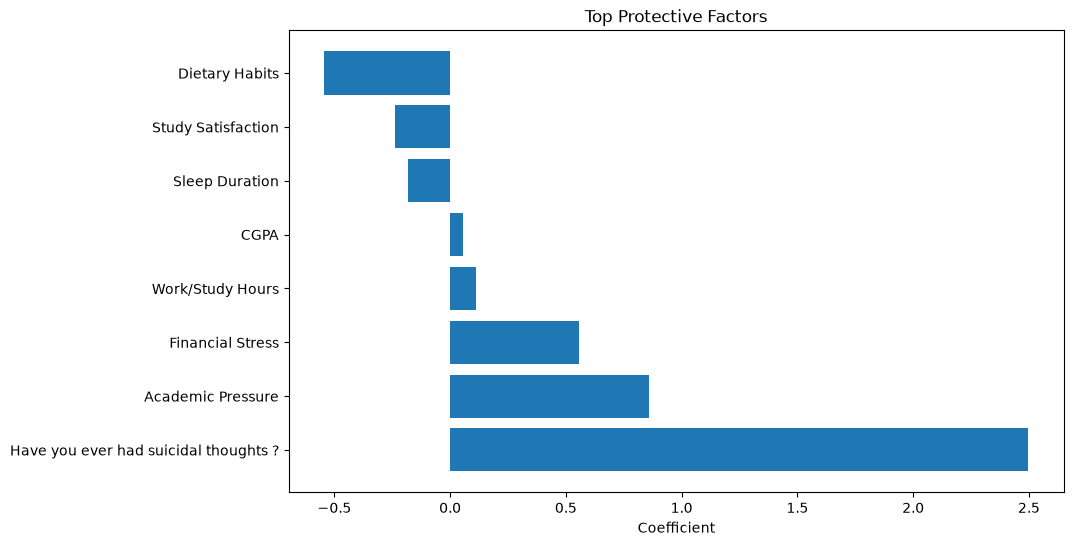

In [30]:
plt.figure(figsize=(10,6))

plt.barh(
    negative.head(10)["Feature"],
    negative.head(10)["Coefficient"]
)

plt.title("Top Protective Factors")

plt.xlabel("Coefficient")

plt.gca().invert_yaxis()

plt.show()

In [31]:
student = X_test.iloc[[0]]

prediction = model.predict(student)[0]

probability = model.predict_proba(student)[0][1]
print(X_test.iloc[[0]])
print("Prediction:", prediction)

print("Probability:", round(probability*100,2), "%")

   Gender  Age  Academic Pressure  CGPA  Study Satisfaction  Sleep Duration  \
0       1   29                  2  9.44                   5               0   

   Dietary Habits  Have you ever had suicidal thoughts ?  Work/Study Hours  \
0               1                                      1                10   

   Financial Stress  Family History of Mental Illness  Degree_B.Arch  \
0                 5                                 0              0   

   Degree_B.Com  Degree_B.Ed  Degree_B.Pharm  Degree_B.Tech  Degree_BA  \
0             1            0               0              0          0   

   Degree_BBA  Degree_BCA  Degree_BE  Degree_BHM  Degree_BSc  Degree_LLB  \
0           0           0          0           0           0           0   

   Degree_LLM  Degree_M.Com  Degree_M.Ed  Degree_M.Pharm  Degree_M.Tech  \
0           0             0            0               0              0   

   Degree_MA  Degree_MBA  Degree_MBBS  Degree_MCA  Degree_MD  Degree_ME  \
0          

In [32]:
contributions = pd.DataFrame({
    "Feature": X_train.columns,
    "Student Value": student.values[0],
    "Coefficient": model.coef_[0]
})

contributions["Contribution"] = (
    contributions["Student Value"]
    * contributions["Coefficient"]
)

contributions = contributions.sort_values(
    "Contribution",
    ascending=False
)

contributions.head(15)

,Feature,Student Value,Coefficient,Contribution
9,Financial Stress,5.00,0.556725,2.783624
7,Have you ever had suicidal thoughts ?,1.00,2.498136,2.498136
2,Academic Pressure,2.00,0.857620,1.715240
8,Work/Study Hours,10.00,0.112493,1.124929
3,CGPA,9.44,0.054379,0.513337
12,Degree_B.Com,1.00,0.085088,0.085088
30,Degree_MBBS,0.00,0.205906,0.000000
23,Degree_LLM,0.00,0.532322,0.000000
24,Degree_M.Com,0.00,0.151482,0.000000
5,Sleep Duration,0.00,-0.182967,-0.000000


In [33]:
contributions = contributions[
    ~contributions["Feature"].str.startswith("Degree_")
]

contributions = contributions[
    ~contributions["Feature"].isin([
        "Age",
        "Gender",
        "Family History of Mental Illness"
    ])
]

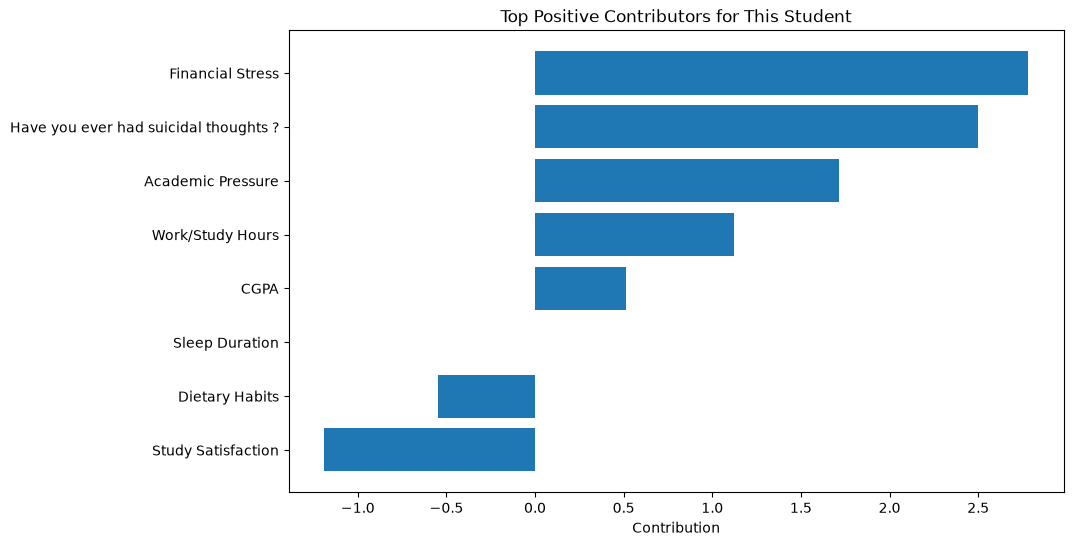

In [34]:
top = contributions.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"],
    top["Contribution"]
)

plt.title("Top Positive Contributors for This Student")

plt.xlabel("Contribution")

plt.gca().invert_yaxis()

plt.show()

In [35]:
bottom = contributions.sort_values(
    "Contribution"
)

bottom.head(10)

,Feature,Student Value,Coefficient,Contribution
4,Study Satisfaction,5.00,-0.238127,-1.190637
6,Dietary Habits,1.00,-0.544967,-0.544967
5,Sleep Duration,0.00,-0.182967,-0.000000
3,CGPA,9.44,0.054379,0.513337
8,Work/Study Hours,10.00,0.112493,1.124929
2,Academic Pressure,2.00,0.857620,1.715240
7,Have you ever had suicidal thoughts ?,1.00,2.498136,2.498136
9,Financial Stress,5.00,0.556725,2.783624


In [36]:
coef_df.to_csv(
    "../data/final/feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


# Summary

The Logistic Regression model was analyzed to understand how different features influence depression prediction.

Key outcomes of this notebook include:

- Ranking features based on coefficient magnitude.
- Identifying risk factors that increase the probability of depression.
- Identifying protective factors that reduce the probability of depression.
- Explaining predictions for individual students using feature contributions.

These explanations provide the foundation for the Wellness Score and Recommendation Engine developed in the next stages of the project.